In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Load your data
df = pd.read_csv('Task 3 and 4_Loan_Data.csv')

# Extract FICO scores and default indicators
fico_scores = df['fico_score'].values
defaults = df['default'].values

print(f"Total borrowers: {len(fico_scores)}")
print(f"FICO score range: {fico_scores.min()} to {fico_scores.max()}")
print(f"Default rate: {defaults.mean():.2%}")


Total borrowers: 10000
FICO score range: 408 to 850
Default rate: 18.51%


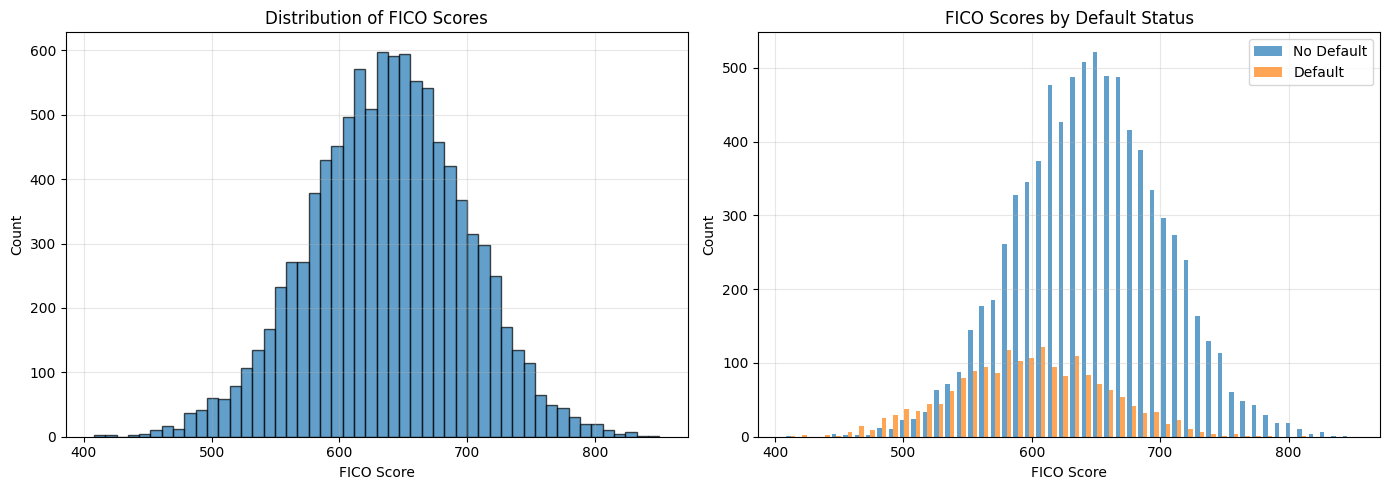


Default rates by FICO range:
300-600: 36.60% (2623 borrowers)
600-650: 17.94% (3111 borrowers)
650-700: 9.61% (2738 borrowers)
700-750: 4.98% (1244 borrowers)
750-850: 2.83% (283 borrowers)


In [2]:
# Plot FICO score distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of all FICO scores
axes[0].hist(fico_scores, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('FICO Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of FICO Scores')
axes[0].grid(True, alpha=0.3)

# FICO scores by default status
axes[1].hist([fico_scores[defaults==0], fico_scores[defaults==1]], 
             bins=50, label=['No Default', 'Default'], alpha=0.7)
axes[1].set_xlabel('FICO Score')
axes[1].set_ylabel('Count')
axes[1].set_title('FICO Scores by Default Status')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate default rate by FICO score ranges
fico_ranges = [(300, 600), (600, 650), (650, 700), (700, 750), (750, 850)]
print("\nDefault rates by FICO range:")
for low, high in fico_ranges:
    mask = (fico_scores >= low) & (fico_scores < high)
    if mask.sum() > 0:
        default_rate = defaults[mask].mean()
        count = mask.sum()
        print(f"{low}-{high}: {default_rate:.2%} ({count} borrowers)")


In [3]:
def calculate_mse(boundaries, fico_scores):
    """
    Calculate MSE for given bucket boundaries
    
    boundaries: list of boundary points (e.g., [600, 700, 750])
    Returns: total mean squared error
    """
    # Add min and max to create complete buckets
    boundaries = sorted([fico_scores.min()] + list(boundaries) + [fico_scores.max()])
    
    total_mse = 0
    
    # For each bucket
    for i in range(len(boundaries) - 1):
        lower = boundaries[i]
        upper = boundaries[i + 1]
        
        # Find all FICO scores in this bucket
        mask = (fico_scores >= lower) & (fico_scores <= upper)
        bucket_scores = fico_scores[mask]
        
        if len(bucket_scores) > 0:
            # Calculate average FICO in this bucket
            bucket_mean = bucket_scores.mean()
            
            # Calculate squared error: (actual - mean)^2
            squared_errors = (bucket_scores - bucket_mean) ** 2
            total_mse += squared_errors.sum()
    
    return total_mse


# Test with some example boundaries
test_boundaries = [600, 670, 740, 800]
mse = calculate_mse(test_boundaries, fico_scores)
print(f"\nMSE with boundaries {test_boundaries}: {mse:,.2f}")



MSE with boundaries [600, 670, 740, 800]: 5,537,379.94


In [4]:
def optimize_mse_buckets(fico_scores, num_buckets):
    """
    Find optimal bucket boundaries using MSE
    
    num_buckets: number of buckets you want (e.g., 5)
    Returns: optimal boundaries
    """
    min_score = fico_scores.min()
    max_score = fico_scores.max()
    
    # Initial guess: equal-width buckets
    initial_boundaries = np.linspace(min_score, max_score, num_buckets + 1)[1:-1]
    
    # Objective function: minimize MSE
    def objective(boundaries):
        return calculate_mse(boundaries, fico_scores)
    
    # Constraint: boundaries must be in order
    bounds = [(min_score + 1, max_score - 1)] * (num_buckets - 1)
    
    # Optimize
    result = minimize(objective, initial_boundaries, method='L-BFGS-B', bounds=bounds)
    
    optimal_boundaries = sorted(result.x)
    optimal_mse = result.fun
    
    return optimal_boundaries, optimal_mse


# Find optimal boundaries for 5 buckets
num_buckets = 5
mse_boundaries, mse_value = optimize_mse_buckets(fico_scores, num_buckets)

print(f"\n=== MSE Optimization Results ===")
print(f"Number of buckets: {num_buckets}")
print(f"Optimal boundaries: {[int(b) for b in mse_boundaries]}")
print(f"MSE: {mse_value:,.2f}")

# Show the buckets
boundaries_with_ends = [fico_scores.min()] + list(mse_boundaries) + [fico_scores.max()]
print("\nBucket ranges:")
for i in range(len(boundaries_with_ends) - 1):
    print(f"Bucket {i+1}: {int(boundaries_with_ends[i])}-{int(boundaries_with_ends[i+1])}")


=== MSE Optimization Results ===
Number of buckets: 5
Optimal boundaries: [496, 584, 673, 761]
MSE: 5,544,208.59

Bucket ranges:
Bucket 1: 408-496
Bucket 2: 496-584
Bucket 3: 584-673
Bucket 4: 673-761
Bucket 5: 761-850


In [5]:
def calculate_log_likelihood(boundaries, fico_scores, defaults):
    """
    Calculate log-likelihood for given boundaries
    Higher is better (we want to maximize this)
    """
    boundaries = sorted([fico_scores.min()] + list(boundaries) + [fico_scores.max()])
    
    log_likelihood = 0
    
    for i in range(len(boundaries) - 1):
        lower = boundaries[i]
        upper = boundaries[i + 1]
        
        # Find borrowers in this bucket
        mask = (fico_scores >= lower) & (fico_scores <= upper)
        
        n_i = mask.sum()  # Total borrowers in bucket
        k_i = defaults[mask].sum()  # Defaults in bucket
        
        if n_i > 0 and k_i > 0 and k_i < n_i:
            # Apply the log-likelihood formula
            # Avoid log(0) by checking conditions
            log_likelihood += (n_i * np.log(n_i) - 
                             k_i * np.log(k_i) - 
                             (n_i - k_i) * np.log(n_i - k_i))
    
    return log_likelihood


# Test with example boundaries
test_ll = calculate_log_likelihood(test_boundaries, fico_scores, defaults)
print(f"\nLog-Likelihood with boundaries {test_boundaries}: {test_ll:.2f}")


Log-Likelihood with boundaries [600, 670, 740, 800]: 4415.00


In [7]:
def optimize_log_likelihood_buckets(fico_scores, defaults, num_buckets):
    """
    Find optimal boundaries using log-likelihood
    """
    min_score = fico_scores.min()
    max_score = fico_scores.max()
    
    initial_boundaries = np.linspace(min_score, max_score, num_buckets + 1)[1:-1]
    
    # Objective: MAXIMIZE log-likelihood = MINIMIZE negative log-likelihood
    def objective(boundaries):
        return -calculate_log_likelihood(boundaries, fico_scores, defaults)
    
    bounds = [(min_score + 1, max_score - 1)] * (num_buckets - 1)
    
    result = minimize(objective, initial_boundaries, method='L-BFGS-B', bounds=bounds)
    
    optimal_boundaries = sorted(result.x)
    optimal_ll = -result.fun  # Convert back to positive
    
    return optimal_boundaries, optimal_ll


# Optimize using log-likelihood
ll_boundaries, ll_value = optimize_log_likelihood_buckets(fico_scores, defaults, num_buckets)

print(f"\n=== Log-Likelihood Optimization Results ===")
print(f"Number of buckets: {num_buckets}")
print(f"Optimal boundaries: {[int(b) for b in ll_boundaries]}")
print(f"Log-Likelihood: {ll_value:.2f}")

boundaries_with_ends = [fico_scores.min()] + list(ll_boundaries) + [fico_scores.max()]
print("\nBucket ranges:")
for i in range(len(boundaries_with_ends) - 1):
    lower = int(boundaries_with_ends[i])
    upper = int(boundaries_with_ends[i+1])
    
    # Calculate default rate in this bucket
    mask = (fico_scores >= lower) & (fico_scores <= upper)
    default_rate = defaults[mask].mean()
    count = mask.sum()
    
    print(f"Bucket {i+1}: {lower}-{upper} | Default rate: {default_rate:.2%} | Count: {count}")



=== Log-Likelihood Optimization Results ===
Number of buckets: 5
Optimal boundaries: [496, 584, 673, 761]
Log-Likelihood: 4313.87

Bucket ranges:
Bucket 1: 408-496 | Default rate: 72.09% | Count: 129
Bucket 2: 496-584 | Default rate: 39.32% | Count: 1765
Bucket 3: 584-673 | Default rate: 16.82% | Count: 5387
Bucket 4: 673-761 | Default rate: 6.68% | Count: 2651
Bucket 5: 761-850 | Default rate: 2.09% | Count: 191



=== Method Comparison ===
        Method           Boundaries  Metric Value
           MSE [496, 584, 673, 761]  5.544209e+06
Log-Likelihood [496, 584, 673, 761]  4.313870e+03


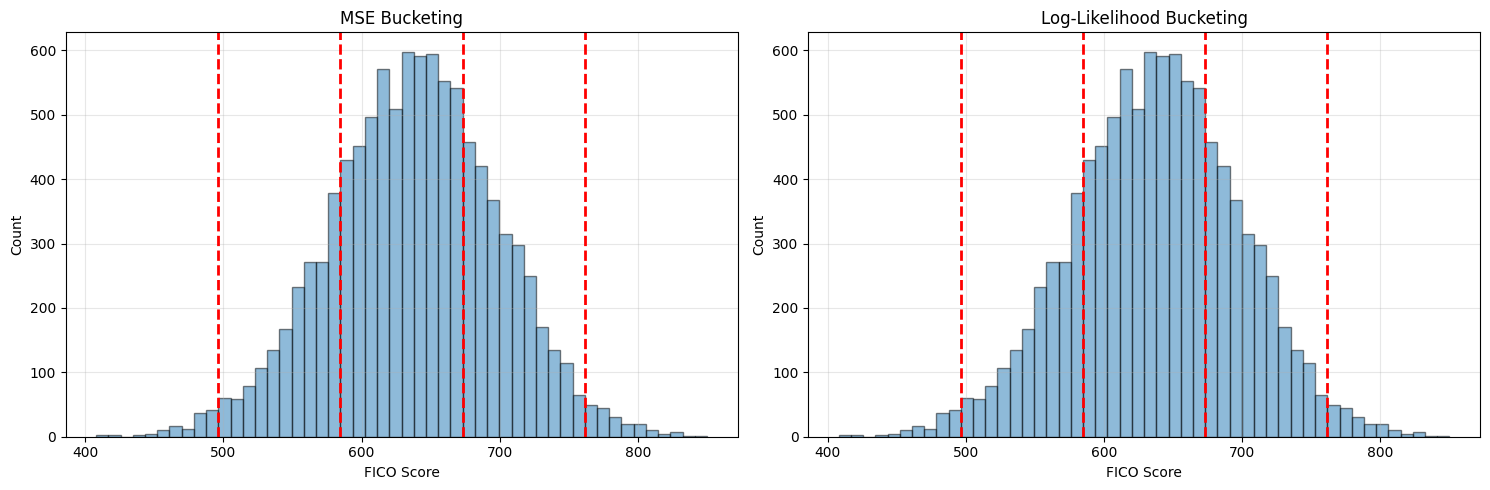

In [8]:
# Compare both methods side by side
comparison = pd.DataFrame({
    'Method': ['MSE', 'Log-Likelihood'],
    'Boundaries': [[int(b) for b in mse_boundaries], [int(b) for b in ll_boundaries]],
    'Metric Value': [mse_value, ll_value]
})

print("\n=== Method Comparison ===")
print(comparison.to_string(index=False))

# Visualize boundaries
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for idx, (method_name, boundaries) in enumerate([('MSE', mse_boundaries), ('Log-Likelihood', ll_boundaries)]):
    ax = axes[idx]
    
    # Plot FICO distribution
    ax.hist(fico_scores, bins=50, alpha=0.5, edgecolor='black')
    
    # Draw boundary lines
    for boundary in boundaries:
        ax.axvline(boundary, color='red', linestyle='--', linewidth=2, label='Boundary')
    
    ax.set_xlabel('FICO Score')
    ax.set_ylabel('Count')
    ax.set_title(f'{method_name} Bucketing')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [9]:
def fico_to_bucket(fico_score, boundaries):
    """
    Map a FICO score to its bucket number (rating)
    Lower rating number = better credit
    
    fico_score: single FICO score
    boundaries: list of boundary points
    Returns: bucket number (1 to num_buckets)
    """
    boundaries = sorted(boundaries)
    
    # Find which bucket this score falls into
    for i, boundary in enumerate(boundaries):
        if fico_score < boundary:
            return i + 1
    
    # If score is above all boundaries, it's in the last bucket
    return len(boundaries) + 1


# Use the better method (Log-Likelihood for credit risk)
final_boundaries = ll_boundaries

# Test the mapping function
test_scores = [550, 650, 700, 750, 820]
print("\n=== FICO Score to Bucket Mapping ===")
print(f"Boundaries: {[int(b) for b in final_boundaries]}")
print("\nTest mappings:")
for score in test_scores:
    bucket = fico_to_bucket(score, final_boundaries)
    print(f"FICO {score} → Bucket {bucket}")

# Apply to entire dataset
df['fico_bucket'] = df['fico_score'].apply(lambda x: fico_to_bucket(x, final_boundaries))
print("\nBucket distribution in dataset:")
print(df['fico_bucket'].value_counts().sort_index())



=== FICO Score to Bucket Mapping ===
Boundaries: [496, 584, 673, 761]

Test mappings:
FICO 550 → Bucket 2
FICO 650 → Bucket 3
FICO 700 → Bucket 4
FICO 750 → Bucket 4
FICO 820 → Bucket 5

Bucket distribution in dataset:
fico_bucket
1     129
2    1762
3    5336
4    2588
5     185
Name: count, dtype: int64
